### **La Transformación Softmax: Fundamentos y Propiedades Matemáticas**

**Softmax** es una de las transformaciones más fundamentales en *deep learning*. En esta lección nos centraremos en comprender sus bases matemáticas, el efecto del parámetro de **temperatura** y la función **LogSoftmax**.

A primera vista, Softmax parece una operación directa y sencilla, pero revela una enorme riqueza técnica y práctica cuando se analiza en profundidad.

---

### **El Pilar de Softmax: La Función Exponencial ($e^x$)**

La arquitectura de Softmax se apoya en la función exponencial natural, $e^x$, donde $e$ es el número irracional de Euler ($e \approx 2.71828$). Existen **dos propiedades clave** de la función exponencial que determinan directamente el comportamiento de Softmax:

1. **Salida estrictamente positiva ($e^x > 0$):**
Es imposible que $e^x$ devuelva un número negativo o igual a cero. A medida que la entrada desciende hacia menos infinito ($x \to -\infty$), $e^x$ se aproxima asintóticamente a $0$, pero sin llegar jamás a tocarlo. Esta característica asegura que todas las salidas puedan ser interpretadas como probabilidades válidas y mayores a cero.
2. **Crecimiento no lineal (amplificación de *logits*):**
La curva de $e^x$ se acelera exponencialmente hacia arriba a medida que $x$ aumenta. Esto significa que diferencias moderadas en las entradas (*logits*) se traducen en diferencias drásticas en la salida. Al pasar un vector por Softmax, **los valores más altos son fuertemente amplificados**, dominando la asignación final de probabilidad.

---


### **Softmax y la Garantía de Distribución de Probabilidad**

Esta propiedad es de gran utilidad porque ayuda al modelo a **focalizar su atención y seleccionar un número muy reducido de tokens** con alta probabilidad dentro de un vocabulario sumamente amplio (amplificando las mejores opciones y atenuando el resto).

---

### **Definición Matemática**

La función **Softmax** es una transformación relativamente simple. Dado un vector de valores reales $\mathbf{z} = [z_1, z_2, \dots, z_K]$ (conocidos como *logits*), la salida para el elemento $i$ se define como:

$$\sigma(\mathbf{z})_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

Es decir: elevamos la constante $e$ al valor del *logit* individual $z_i$ y dividimos el resultado entre la suma de las exponenciales de todos los *logits* del vector.

> **Nota sobre la notación ($\sigma$):** La letra griega $\sigma$ (sigma) suele usarse en estadística para la desviación estándar y en *machine learning* para representar funciones de activación no lineales (como la función Sigmoide). En este contexto, se emplea como la notación estándar de la función Softmax.

---

### **Las dos condiciones de una Distribución de Probabilidad**

Independientemente de lo grandes, pequeños o negativos que sean los valores iniciales de $\mathbf{z}$, al aplicar Softmax se garantiza matemáticamente que el vector resultante cumple con las dos reglas de una **distribución de probabilidad válida**:

1. **Valores acotados en $(0, 1)$:** Dado que $e^{z_i} > 0$ para cualquier $z_i$, cada elemento transformado será estrictamente mayor que $0$ y menor que $1$.
2. **Suma igual a $1$:** La normalización por el denominador garantiza que la suma de todas las probabilidades asignadas a las categorías sea exactamente $1$:

$$\sum_{i=1}^{K} \sigma(\mathbf{z})_i = 1$$

---


### **¿Qué es una Distribución de Probabilidad?**

Es una función matemática que **asigna sucesos o eventos a sus respectivas probabilidades de ocurrencia**. Estos eventos pueden clasificarse en dos tipos:

* **Observaciones continuas:** Variables medidas en un rango numérico ininterrumpido (como los ingresos, la altura o el tiempo).
* **Eventos discretos:** Categorías finitas o contables (como el género de una película, las letras del alfabeto o los *tokens* dentro de un LLM).

Cualquier función que asocie sucesos con la probabilidad de que estos ocurran u observen se define como una función de probabilidad.

---

### **Las Dos Condiciones Formales (Axiomas de Probabilidad)**

Para que una función sea considerada formalmente una distribución de probabilidad válida, debe cumplir obligatoriamente dos condiciones:

#### **1. Condición de No Negatividad (*Non-negativity condition*)**

Todos los valores devueltos por la función deben ser mayores o iguales a cero. No existen las probabilidades negativas:

$$p(x) \ge 0 \quad \forall x$$

#### **2. Condición de Normalización (*Normalization condition*)**

La suma total de las probabilidades atribuibles a todos los eventos posibles dentro del espacio muestral debe ser exactamente **1**:

* **Para eventos discretos (*tokens*, categorías, letras):** Se suman las probabilidades individuales mediante un sumatorio:

$$\sum_{i} P(x_i) = 1$$

* **Para variables continuas (ingresos, mediciones físicas):** Se calcula el área total bajo la curva mediante una integral sobre todo el dominio:

$$\int_{-\infty}^{\infty} f(x) \, dx = 1$$

---


### **Softmax: De Números Arbitrarios a una Distribución de Probabilidad**

Básicamente, cuando aplicamos la función Softmax a una colección de **números** (los cuales por sí mismos no representan una probabilidad), la transformación los convierte formalmente en una **distribución de probabilidades válida**.

El uso del término **A.U. (*Arbitrary Units* / Unidades Arbitrarias)** en los ejes de los gráficos indica que la escala o magnitud inicial de los datos de entrada no importa: mientras sean valores numéricos reales, la función puede procesarlos. No afecta cuántos elementos tenga el vector, si los valores son negativos o si son mucho mayores a $1$; la salida final estará siempre acotada y normalizada como una distribución de probabilidad.

---

### **Puntos Clave de la Transformación**

* **Entrada (*Logits* en A.U.):** Un vector de valores pertenecientes a $\mathbb{R}^K$. Pueden ser negativos ($z_i < 0$), cero o arbitrariamente grandes ($z_i > 1$).
* **Dimensiones flexibles:** No importa el número de clases o categorías ($K$); Softmax funciona igual para $2$ categorías o para vocabularios de más de $100.000$ *tokens*.
* **Salida acotada:** Cada elemento transformado cumple estrictamente $0 < P(x_i) < 1$.
* **Suma unitaria:** La suma total de todas las salidas es exactamente $1.0$ ($\sum P(x_i) = 1$).

---


In [1]:
# parametro T

### **El Parámetro de Temperatura ($T$) en Softmax**

Podemos modificar la función de probabilidad introduciendo el **parámetro de temperatura ($T$)** (a veces parametrizado mediante la temperatura inversa $\beta = 1/T$). Este parámetro controla la escala, "suavidad" (*softness*) o concentración de la distribución resultante.

---

### **Notación Matemática: Uso de $\exp(\cdot)$**

Cuando el exponente de la función natural $e^x$ se vuelve más complejo —como al incluir divisiones o fracciones—, en la literatura científica se suele reemplazar la notación $e^{x}$ por la función $\exp(x)$. Ambas expresiones son matemáticamente equivalentes:

$$\exp\left(\frac{z_i}{T}\right) \equiv e^{\frac{z_i}{T}}$$

Todo lo que se encuentra dentro del paréntesis de $\exp(\dots)$ representa el argumento que se eleva sobre la base $e$.

---

### **Fórmula de Softmax con Temperatura**

Aplicando la escala de temperatura a cada *logit* $z_i$, la ecuación general se define como:

$$\sigma(\mathbf{z})_i = \frac{\exp\left(\frac{z_i}{T}\right)}{\sum_{j=1}^{K} \exp\left(\frac{z_j}{T}\right)}$$

* **Caso base ($T = 1$):**
Cuando la temperatura es igual a $1$, la división $z_i / 1 = z_i$ deja los *logits* inalterados. En este escenario, la ecuación se reduce exactamente a la **fórmula original de Softmax**:

$$\sigma(\mathbf{z})_i = \frac{\exp(z_i)}{\sum_{j=1}^{K} \exp(z_j)}$$

---


### **El Parámetro de Temperatura ($T$): Qué Hace y Para Qué Sirve**

El parámetro de **temperatura ($T$)** sirve para **controlar el nivel de aleatoriedad, diversidad o determinismo** en la salida del modelo (especialmente útil en la generación de texto con LLMs).

---

### **1. ¿Qué hace matemáticamente?**

Al dividir cada *logit* ($z_i$) por el valor $T$ antes de pasarlo por Softmax ($\exp(z_i / T)$), se altera directamente la brecha o "contraste" entre las puntuaciones:

#### **Temperaturas Altas ($T > 1$, p. ej. $1.5$ o $2.0$)**

* **Mecanismo:** Al dividir los *logits* entre un número mayor a $1$, las distancias numéricas entre ellos se reducen.
* **Efecto en la distribución:** La curva de probabilidad se vuelve más **plana y uniforme** (*flattened distribution*).
* **Resultado:** Los *tokens* que originalmente tenían probabilidades bajas o medias se acercan al líder. El modelo atenúa a los candidatos obvios y le da más oportunidad a opciones secundarias, generando respuestas más diversas, impredecibles o "creativas".

#### **Temperaturas Bajas ($T < 1$, p. ej. $0.1$ o $0.2$)**

* **Mecanismo:** Al dividir entre un número entre $0$ y $1$, la diferencia entre los *logits* se amplifica exponencialmente.
* **Efecto en la distribución:** La curva se vuelve extremadamente **puntiaguda** (*peaked*).
* **Resultado:** El *token* con el *logit* más alto absorbe casi toda la probabilidad (tendiendo a $1.0$), mientras que los demás caen cerca de $0$.

---

### **2. Resumen de los 3 Escenarios Clave**

| Valor de $T$ | Distribución | Comportamiento del Modelo | Caso de Uso Ideal |
| --- | --- | --- | --- |
| **$T > 1.0$** (p. ej. $1.5$) | Plana / Homogénea | **Alta diversidad / Aleatorio:** Explora combinaciones raras o creativas. | Escritura creativa, lluvia de ideas, poesía. |
| **$T = 1.0$** | Estándar | **Equilibrado:** Mantiene la distribución original aprendida en entrenamiento. | Conversación general, resúmenes. |
| **$T \to 0$** (p. ej. $0.1$) | Puntiaguda / Concentrada | **Determinista / Conservador:** Elige siempre la opción más probable (*Greedy Search*). | Generación de código, matemáticas, extracción de datos. |

---


In [2]:
# Logsoftmax

### **LogSoftmax: Estabilidad Numérica y Optimización a Gran Escala**

El concepto de **LogSoftmax** consiste simplemente en calcular la función Softmax y, a continuación, aplicar el logaritmo natural ($\ln$) sobre el resultado:

$$\text{LogSoftmax}(z_i) = \ln(\text{Softmax}(z_i)) = z_i - \ln\left( \sum_{j=1}^{K} e^{z_j} \right)$$

---

### **¿Por qué es fundamental en modelos con grandes vocabularios?**

1. **El problema de las probabilidades diminutas (*Underflow*):**
Cuando un LLM intenta predecir el siguiente token dentro de un vocabulario masivo (de $100.000$ o más tokens), la inmensa mayoría de los términos son irrelevantes en ese contexto. Como resultado, casi todos los tokens reciben una probabilidad devuelta por Softmax extremadamente cercana a cero (por ejemplo, $10^{-9}$). En computación de punto flotante, manejar números tan pequeños genera problemas de subdesbordamiento (*underflow*), donde el hardware los redondea a $0$ absoluto, perdiendo información y anulando los gradientes.
2. **Efecto de "estiramiento" del logaritmo:**
El logaritmo natural mapea el intervalo comprimido de probabilidades $(0, 1]$ hacia un rango continuo de números negativos en $(-\infty, 0]$. Esto "estira" numéricamente las cifras diminutas:
* Una probabilidad de $0.000045$ pasa a ser $\approx -10.00$.
* Una probabilidad de $0.000000001$ pasa a ser $\approx -20.72$.
Al transformar diferencias imperceptibles en una escala numérica diferenciable, el algoritmo de optimización (como AdamW) puede distinguir claramente entre un token poco probable y uno casi imposible.


3. **Estabilidad en el entrenamiento:**
Al evitar operaciones que tiendan a $0$ o a $\infty$, la combinación de `LogSoftmax` junto con `NLLLoss` (Pérdida de Verosimilitud Negativa) —o directamente `nn.CrossEntropyLoss` en PyTorch— permite al optimizador seguir calculando gradientes estables para **suprimir tokens irrelevantes y acelerar la convergencia**.

---

In [3]:
# en modelos de lenguaje el el numero de categorias pueden ser el numero de tokens y eso es realmente masivo 100k in GPT4

In [5]:
# Importar librerías
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# vector plots
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

## Implementación en Numpy

In [6]:
# lista de numeros

z = [1,2,3]

# computo softmax resultado

#numerador
num = np.exp(z)
#denominador
den = np.sum(np.exp(z))
#signma num entre den
sigma = num / den

In [7]:
print(sigma)
#la suma de las probabilidades
print(np.sum(sigma))

[0.09003057 0.24472847 0.66524096]
1.0


La Amplificación No Lineal en SoftmaxLa función Softmax no preserva la proporcionalidad lineal de los datos de entrada (logits). Debido al comportamiento de la función exponencial ($e^z$), Softmax amplifica drásticamente las diferencias: incrementos pequeños en la entrada generan saltos exponenciales en la probabilidad de salida.Demostración Numérica con $z = [1, 2, 3]$Si tomamos el vector $z = [1, 2, 3]$ y calculamos su Softmax:Proporción lineal en las entradas:$2$ es el doble de $1$ ($2 = 2 \times 1$).$3$ es $1.5$ veces $2$ ($3 = 1.5 \times 2$).Proporción en la salida Softmax ($\sigma$):$\sigma(1) \approx 0.090$ ($9.0\%$)$\sigma(2) \approx 0.245$ ($24.5\%$)$\sigma(3) \approx 0.665$ ($66.5\%$)El efecto amplificador:Al pasar de $1$ a $2$, la probabilidad en Softmax no se duplica, sino que se multiplica por $e^1 \approx 2.72$ ($0.245 / 0.090 \approx 2.72$).Al pasar de $2$ a $3$, la probabilidad vuelve a multiplicarse por $2.72$ ($0.665 / 0.245 \approx 2.72$).Efecto extremo en valores mayores (ejemplo con $z = 8$):Si sustituimos el valor $3$ por un $8$ en el vector ($z = [1, 2, 8]$):En la escala lineal, $8$ es solo $4$ veces mayor que $2$.Sin embargo, en la escala de Softmax, la diferencia entre $e^8$ y $e^2$ es de $e^6 \approx 403.4$. La probabilidad para $z=8$ se vuelve prácticamente de $0.997$ ($99.7\%$), aplastando a los demás valores por órdenes de magnitud.

Desde este pequeño conjunto de datos se puede ver la transformacion no lineal

In [8]:
# Repetir con algunos números enteros aleatorios
z = np.random.randint(-5,high=15,size=25)
print(z)


[ 3 -5 12  0 13  8 -4  1  7 13  5  6 14 13 13  0 11  7 -4 -2 -4 11 -1  2
  2]


In [9]:
# Calcular el resultado de softmax
num = np.exp(z)
den = np.sum( num )
sigma = num / den

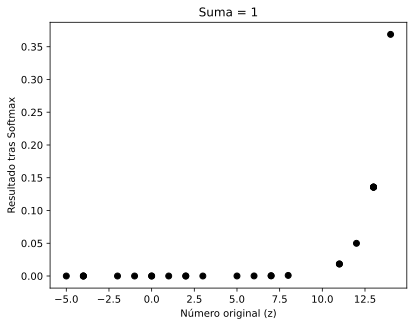

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Comparar
plt.plot(z, sigma, 'ko')
plt.xlabel('Número original (z)')
plt.ylabel('Resultado tras Softmax')
# plt.yscale('log')
plt.title('Suma = %g' % np.sum(sigma))
plt.show()

Imaginemos que estos **25 puntos representan un vocabulario reducido de 25 fichas (tokens candidates)** que el modelo está evaluando para predecir la siguiente palabra de un texto:

* **Eje X (`Original number z`):** Es el puntaje bruto (*logit*) que la red neuronal asignó internamente a cada una de las 25 fichas.
* **Eje Y (`Softmaxified Result`):** Es la probabilidad real ($0.0$ a $1.0$) de que esa ficha sea seleccionada como la siguiente palabra, tras pasar por la función Softmax.

---

### **Puntos clave del análisis:**

#### **1. El "efecto silenciador" sobre la mayoría (de $z = -4$ a $z = 8$)**

Casi 20 de las 25 fichas terminan prácticamente pegadas al suelo con una probabilidad de $0.00$.

Incluso si comparas una ficha con $z = -3$ frente a una con $z = 8$, en la escala lineal $8$ parece un número mucho mayor. Sin embargo, al pasar por Softmax, la exponencial de los puntajes más altos domina de tal manera el denominador que **aplasta a todas las fichas medias y bajas**, convirtiéndolas en opciones prácticamente imposibles de seleccionar.

#### **2. Concentración exponencial en el "Top 3"**

La probabilidad no se distribuye de forma proporcional; se concentra agresivamente en la cúspide:

* La ficha con $z \approx 11$ recibe apenas un **$4\%$** de probabilidad ($0.04$).
* La ficha con $z \approx 12$ alcanza un **$10\%$** ($0.10$).
* La ficha ganadora con $z \approx 13$ absorbe por sí sola casi el **$28\%$** ($0.28$) de toda la masa de probabilidad.

#### **3. Garantía de Normalización (`Sum = 1`)**

A pesar de esta disparidad tan extrema entre el líder y los demás, si sumas la probabilidad de las 25 fichas, el resultado es exactamente **$1.0$** ($100\%$).

---

### **¿Qué nos enseña esto sobre los LLMs?**

Este gráfico ilustra el comportamiento natural de Softmax a Temperatura $1.0$: actúa como un filtro que **suprime el ruido** de la inmensa mayoría del vocabulario y centra la atención del modelo en apenas $2$ o $3$ candidatos viables.

Si quisiéramos que las fichas que quedaron silenciadas cerca de $0$ tuvieran alguna oportunidad de salir (para respuestas más creativas), tendríamos que subir la **Temperatura ($T > 1$)** para "subir el suelo" y aplanar esta curva.

In [ ]:
# Usando PYTORCH

In [11]:
zTorch = torch.tensor(z, dtype=torch.float64)

# Usando una función
F.softmax(zTorch)#, dim=-1) veremos en algunos casos la dimension del ultimo tensor que corresponde a los logits de los tokens

/tmp/ipykernel_4603/1740344926.py:4: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  F.softmax(zTorch)#, dim=-1) veremos en algunos casos la dimension del ultimo tensor que corresponde a los logits de los tokens


tensor([6.1602e-06, 2.0665e-09, 4.9917e-02, 3.0670e-07, 1.3569e-01, 9.1426e-04,
        5.6174e-09, 8.3369e-07, 3.3634e-04, 1.3569e-01, 4.5518e-05, 1.2373e-04,
        3.6884e-01, 1.3569e-01, 1.3569e-01, 3.0670e-07, 1.8363e-02, 3.3634e-04,
        5.6174e-09, 4.1507e-08, 5.6174e-09, 1.8363e-02, 1.1283e-07, 2.2662e-06,
        2.2662e-06], dtype=torch.float64)

In [ ]:
## Añadiendo una temperatura

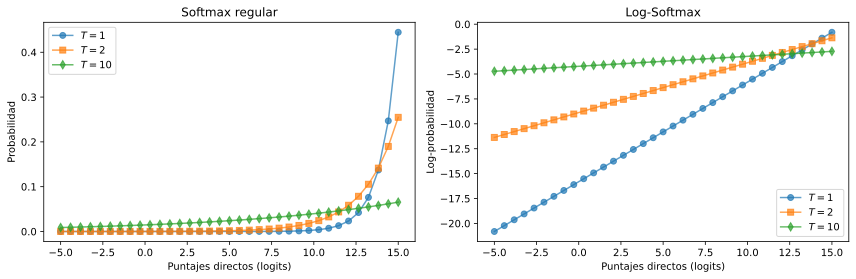

In [12]:
# Lista de temperaturas a usar (T = 1/beta)
temperatures = [1, 2, 10]

rawscores = torch.linspace(-5, 15, 35)
shapes = 'osd'

_, axs = plt.subplots(1, 2, figsize=(12, 4))
for temp, s in zip(temperatures, shapes):

  # Escalar los puntajes por la temperatura
  heatedScores = rawscores / temp

  # Y graficar
  axs[0].plot(rawscores, F.softmax(heatedScores, dim=0), f'{s}-', alpha=0.7, label=rf'$T={temp}$')
  axs[1].plot(rawscores, F.log_softmax(heatedScores, dim=0), f'{s}-', alpha=0.7, label=rf'$T={temp}$')


axs[0].legend()
axs[0].set(xlabel='Puntajes directos (logits)', ylabel='Probabilidad', title='Softmax regular')
axs[1].legend()
axs[1].set(xlabel='Puntajes directos (logits)', ylabel='Log-probabilidad', title='Log-Softmax')

plt.tight_layout()
plt.show()

### **Análisis de la Escala de Temperatura en Softmax y LogSoftmax**

Partiendo de un vector de puntuaciones brutas o *logits* (`rawscores = torch.linspace(-5, 15, 35)`), que contienen números negativos y no suman 1, aplicamos la transformación Softmax ajustada por una escala de temperatura $T$:

$$\text{Softmax}(z_i, T) = \frac{\exp\left(\frac{z_i}{T}\right)}{\sum_{j} \exp\left(\frac{z_j}{T}\right)}$$

---

### **1. Gráfica Izquierda: Softmax Regular y la Temperatura**

* **$T = 1$ (Curva azul):** Es la transformación estándar. El valor más alto ($15$) acapara casi el **$45\%$** de toda la masa de probabilidad, mientras que las primeras 20 puntuaciones quedan aplastadas prácticamente en $0.0$.
* **$T = 2$ (Curva naranja):** Al dividir los *logits* entre $2$, las distancias se atenúan. El pico baja a un **$25\%$** y la probabilidad se distribuye más suavemente entre los valores adyacentes.
* **$T = 10$ (Curva verde):** Con una temperatura alta, la curva se vuelve casi **completamente plana**. Las probabilidades se distribuyen de manera cuasi-uniforme entre los 35 elementos (aproximándose a $1/35 \approx 0.028$).

---

### **2. Gráfica Derecha: Log-Softmax y la Preservación de Escala**

Al aplicar la función logarítmica, la relación exponencial se transforma en una relación **lineal en la escala del gráfico**:

* **Estiramiento de la masa inferior:** En la gráfica de Softmax normal, todos los valores entre $-5$ y $7.5$ parecen idénticos a $0.0$. En Log-Softmax, vemos que con $T=1$, un valor de $-5$ corresponde a una log-probabilidad de **$-20.8$** ($e^{-20.8} \approx 9 \times 10^{-10}$).
* **Gradientes informativos:** En lugar de perder esa información por redondeo de pantalla, Log-Softmax conserva exactamente cuán "improbable" es cada token, permitiendo que el optimizador calcule gradientes útiles.

---

### **3. ¿Por qué PyTorch ofrece `F.log_softmax` en lugar de hacer `torch.log(torch.softmax(x))`?**

Si se calcula ingenuamente `torch.log(torch.softmax(x))`, el código realiza dos operaciones peligrosas para la precisión de punto flotante (*float32*):

1. **Riesgo de *Overflow*:** Elevar números grandes a la exponencial ($\exp(15)$) puede generar valores excesivamente altos que desbordan la memoria (*NaN* o $\infty$).
2. **Riesgo de *Underflow*:** Para números negativos, $\exp(-5)$ produce valores tan cercanos a cero que Softmax los redondea a $0.0$. Luego, intentar calcular $\ln(0)$ genera un error de $-\infty$.

#### **El truco de estabilidad computacional (*LogSumExp trick*)**

La función nativa `F.log_softmax` simplifica la ecuación algebraicamente antes de ejecutarla en C++/CUDA:

$$\ln\left(\frac{e^{z_i}}{\sum_j e^{z_j}}\right) = z_i - \ln\left( \sum_j e^{z_j} \right)$$

PyTorch resta el valor máximo del vector ($\max(z)$) antes de calcular la suma de exponenciales, evitando por completo que los números se vuelvan demasiado grandes o caigan en cero absoluto. Por esta razón, **siempre se debe preferir `F.log_softmax**` en pipelines de entrenamiento.

---


In [13]:
# los modelos de LLMs reales suelen acercarse a valores mas cercanos a 1

En la práctica, los LLMs en producción suelen usar temperaturas cercanas a **$T = 1.0$** (frecuentemente entre $0.7$ y $1.0$) porque representan el **punto de equilibrio ideal**:

* **Si $T \to 0$ (muy baja):** El texto se vuelve robótico, repetitivo y sumamente rígido (siempre elige la opción más obvia).
* **Si $T \gg 1$ (muy alta):** La salida pierde coherencia lógica, se llena de alucinaciones y genera "sopa de palabras".
* **Cerca de $1.0$ (el punto óptimo):** Preserva la estructura lógica y gramatical aprendida durante el entrenamiento, manteniendo la fluidez, naturalidad y la creatividad en las respuestas.